<a href="https://colab.research.google.com/github/Mikomijie/LunchPad/blob/main/oil_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Volve production data.xlsx to Volve production data.xlsx


In [5]:
import pandas as pd
oil = pd.read_excel("Volve production data.xlsx", sheet_name = "Monthly Production Data" ,skiprows = [1])
oil.head()
oil.columns.tolist()

['Wellbore name',
 'NPDCode',
 'Year',
 'Month',
 'On Stream',
 'Oil',
 'Gas',
 'Water',
 'GI',
 'WI']

In [7]:
print(oil.shape)
print(oil.isnull().sum())
print(oil['Wellbore name'].unique())
print(oil.dtypes)

(526, 10)
Wellbore name      0
NPDCode            0
Year               0
Month              0
On Stream         11
Oil              215
Gas              215
Water            215
GI               526
WI               325
dtype: int64
['15/9-F-1 C' '15/9-F-11' '15/9-F-12' '15/9-F-14' '15/9-F-15 D' '15/9-F-4'
 '15/9-F-5']
Wellbore name     object
NPDCode            int64
Year               int64
Month              int64
On Stream        float64
Oil              float64
Gas              float64
Water            float64
GI               float64
WI               float64
dtype: object


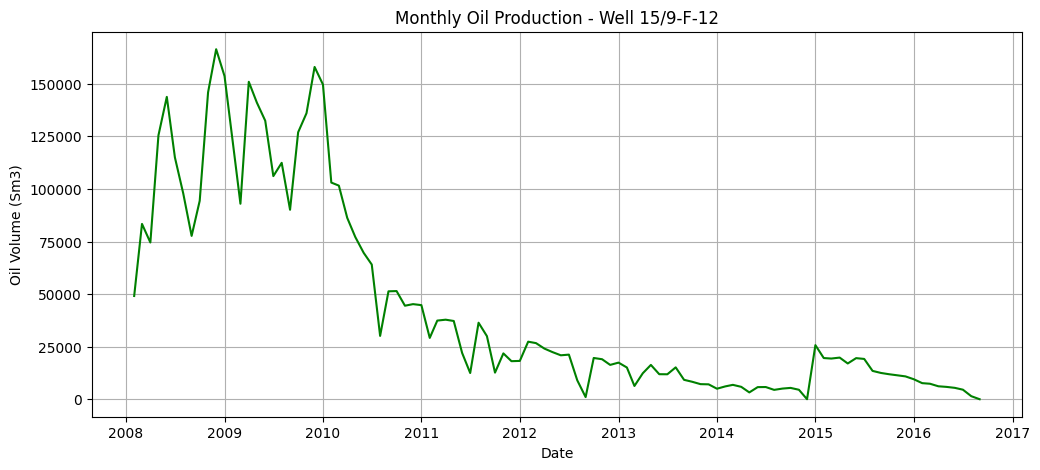

In [10]:
well = oil[oil['Wellbore name']== "15/9-F-12"].copy()
well = well[['Year', 'Month', 'Oil']].dropna()
well = well.sort_values(['Year', 'Month']).reset_index(drop = True)
well['Date'] = pd.to_datetime(well[['Year', 'Month']].assign(Day =1))

import matplotlib.pyplot as plt
plt.figure(figsize=(12,5))
plt.plot(well['Date'], well['Oil'], color='green')

plt.xlabel("Date")
plt.title("Monthly Oil Production - Well 15/9-F-12")
plt.ylabel("Oil Volume (Sm3)")
plt.grid(True)
plt.show()